# clustering overrides

In [1]:
import pandas as pd

df = pd.read_parquet("../temp/5FT0131/context_windows.parquet")

df.head()

,Timestamp,iQC1.iQCMode,EH_not_localized.EH_not_localized,VP_RP_80.Latitude,VP_RP_80.Longitude,EEC2_Engine.AccelPedalPos1,CCVS1_Engine.BrakeSwitch,EBC1_Brakes.BrakePedalPos,CCVS1_Engine.WheelBasedVehicleSpeed,ACC1_Radar.DistanceToForwardVehicle,...,IQVLPE1.iQGrossVehicleWeightEst,EEC1_Engine.EngSpeed,EEC1_Engine.ActualEngPercentTorque,EEC1_Engine.DriversDemandEngPercentTorque,ERC1_Retarder.ActualRetarderPercentTorque,truck_id,event_id,override_type,override_ts,is_override_point
0,2025-05-30 00:33:54.215,3.0,0.0,41.347643,-87.815917,0.0,0.0,102.0,102.79,91.10,...,33898.0,1276.50,51.0,0.0,0.0,5FT0131,0,THROTTLE_OVERRIDE,2025-05-30 00:34:04.228,False
1,2025-05-30 00:33:54.315,3.0,0.0,41.347540,-87.815935,0.0,0.0,102.0,102.82,91.10,...,33898.0,1275.25,51.0,0.0,0.0,5FT0131,0,THROTTLE_OVERRIDE,2025-05-30 00:34:04.228,False
2,2025-05-30 00:33:54.416,3.0,0.0,41.347540,-87.815935,0.0,0.0,102.0,102.78,91.07,...,33898.0,1279.00,51.0,0.0,0.0,5FT0131,0,THROTTLE_OVERRIDE,2025-05-30 00:34:04.228,False
3,2025-05-30 00:33:54.516,3.0,0.0,41.347489,-87.815944,0.0,0.0,102.0,102.77,91.04,...,33898.0,1278.00,51.0,0.0,0.0,5FT0131,0,THROTTLE_OVERRIDE,2025-05-30 00:34:04.228,False
4,2025-05-30 00:33:54.616,3.0,0.0,41.347489,-87.815944,0.0,0.0,102.0,102.75,91.01,...,33899.0,1278.00,51.0,0.0,0.0,5FT0131,0,THROTTLE_OVERRIDE,2025-05-30 00:34:04.228,False


In [2]:
import pandas as pd
from pathlib import Path

parquet_files = list(Path("../temp").rglob("context_windows.parquet"))

df = pd.concat(
    (pd.read_parquet(p) for p in parquet_files),
    ignore_index=True
)

print(df.shape)

(1617447, 33)


In [3]:
df.override_type.value_counts()

override_type
THROTTLE_OVERRIDE       1595538
THROTTLE_BRAKE_PEDAL      21909
Name: count, dtype: int64

In [4]:
df = df[df.override_type == "THROTTLE_OVERRIDE"]

In [5]:
# ensure both columns are strings
df["truck_id"] = df["truck_id"].astype(str)
df["event_id"] = df["event_id"].astype(str)

# create globally unique event_id
df["event_id"] = df["truck_id"] + "_" + df["event_id"]

df.head()

,Timestamp,iQC1.iQCMode,EH_not_localized.EH_not_localized,VP_RP_80.Latitude,VP_RP_80.Longitude,EEC2_Engine.AccelPedalPos1,CCVS1_Engine.BrakeSwitch,EBC1_Brakes.BrakePedalPos,CCVS1_Engine.WheelBasedVehicleSpeed,ACC1_Radar.DistanceToForwardVehicle,...,EEC1_Engine.DriversDemandEngPercentTorque,ERC1_Retarder.ActualRetarderPercentTorque,truck_id,event_id,override_type,override_ts,is_override_point,PCC1.RoadwayNextGradeDis,PCC1.RoadwayNextGrade,IQCU_IMU_Status_4.PathCurvature
0,2025-05-01 00:32:05.831,3.0,0.0,43.468854,-70.513885,0.0,0.0,0.0,107.50,255.0,...,0.0,0.0,5FT0607,5FT0607_0,THROTTLE_OVERRIDE,2025-05-01 00:32:15.846,False,NaN,NaN,NaN
1,2025-05-01 00:32:05.931,3.0,0.0,43.468854,-70.513885,0.0,0.0,0.0,107.37,255.0,...,0.0,0.0,5FT0607,5FT0607_0,THROTTLE_OVERRIDE,2025-05-01 00:32:15.846,False,NaN,NaN,NaN
2,2025-05-01 00:32:06.031,3.0,0.0,43.468911,-70.513805,0.0,0.0,0.0,107.43,255.0,...,0.0,0.0,5FT0607,5FT0607_0,THROTTLE_OVERRIDE,2025-05-01 00:32:15.846,False,NaN,NaN,NaN
3,2025-05-01 00:32:06.131,3.0,0.0,43.468911,-70.513805,0.0,0.0,0.0,107.48,255.0,...,0.0,0.0,5FT0607,5FT0607_0,THROTTLE_OVERRIDE,2025-05-01 00:32:15.846,False,NaN,NaN,NaN
4,2025-05-01 00:32:06.231,3.0,0.0,43.468947,-70.513751,0.0,0.0,0.0,107.39,255.0,...,0.0,0.0,5FT0607,5FT0607_0,THROTTLE_OVERRIDE,2025-05-01 00:32:15.846,False,NaN,NaN,NaN


## tensors

In [6]:
exclude_cols = [
    "Timestamp",
    "truck_id",
    "event_id",
    "override_type",
    "override_ts",
    "is_override_point"
]

feature_cols = [c for c in df.columns if c not in exclude_cols]

print(len(feature_cols), "features")

27 features


In [7]:
import numpy as np

events = []
event_ids = []

for event_id, g in df.groupby("event_id"):

    # g = g.sort_values("Timestamp")

    X = g[feature_cols].values.astype(np.float32)

    if len(X) == 201:   # enforce fixed window
        events.append(X)
        event_ids.append(event_id)

X = np.stack(events)

print("Tensor shape:", X.shape)

N, T, F = X.shape

Tensor shape: (7938, 201, 27)


In [8]:
# detect constant features
feature_std = X.reshape(-1, F).std(axis=0)

valid_features = feature_std > 1e-6

print("Removed constant features:", np.sum(~valid_features))

X = X[:, :, valid_features]

feature_cols = [f for f, keep in zip(feature_cols, valid_features) if keep]

N, T, F = X.shape

Removed constant features: 5


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_2d = X.reshape(-1, F)

X_scaled = scaler.fit_transform(X_2d)

X_scaled = X_scaled.reshape(N, T, F)

## representation learning

In [15]:
import torch

device = torch.device("mps" if torch.mps.is_available() else "cpu")

print("Using device:", device)

X_tensor = torch.tensor(X_scaled).float().to(device)

print(X_tensor.shape)

Using device: mps
torch.Size([7938, 201, 22])


200 x F

   ↓

LSTM encoder

   ↓

latent vector (32)

   ↓

LSTM decoder

   ↓

reconstruct 200 x F

In [16]:
import torch.nn as nn

class LSTMAutoencoder(nn.Module):

    def __init__(self, n_features, latent_dim=32):
        super().__init__()

        self.encoder = nn.LSTM(
            input_size=n_features,
            hidden_size=128,
            num_layers=2,
            batch_first=True
        )

        self.fc_enc = nn.Linear(128, latent_dim)

        self.fc_dec = nn.Linear(latent_dim, 128)

        self.decoder = nn.LSTM(
            input_size=128,
            hidden_size=n_features,
            num_layers=2,
            batch_first=True
        )

    def encode(self, x):

        _, (h, _) = self.encoder(x)

        h = h[-1]

        z = self.fc_enc(h)

        return z

    def decode(self, z, seq_len):

        h = self.fc_dec(z)

        h = h.unsqueeze(1).repeat(1, seq_len, 1)

        out, _ = self.decoder(h)

        return out

    def forward(self, x):

        seq_len = x.shape[1]

        z = self.encode(x)

        out = self.decode(z, seq_len)

        return out, z

In [17]:
latent_dim = 32

model = LSTMAutoencoder(
    n_features=F,
    latent_dim=latent_dim
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

criterion = nn.MSELoss()

In [18]:
from torch.utils.data import DataLoader, TensorDataset

dataset = TensorDataset(X_tensor)

loader = DataLoader(
    dataset,
    batch_size=512,
    shuffle=True
)

epochs = 40

for epoch in range(epochs):

    total_loss = 0

    for (batch,) in loader:

        optimizer.zero_grad()

        recon, z = model(batch)

        loss = criterion(recon, batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: {total_loss/len(loader):.4f}")

Epoch 1: 0.9768
Epoch 2: 0.9012
Epoch 3: 0.8610
Epoch 4: 0.8415
Epoch 5: 0.8311
Epoch 6: 0.8232
Epoch 7: 0.8192
Epoch 8: 0.8127
Epoch 9: 0.8012
Epoch 10: 0.7947
Epoch 11: 0.7898
Epoch 12: 0.7808
Epoch 13: 0.7799
Epoch 14: 0.7743
Epoch 15: 0.7719
Epoch 16: 0.7662
Epoch 17: 0.7609
Epoch 18: 0.7554
Epoch 19: 0.7518
Epoch 20: 0.7607
Epoch 21: 0.7608
Epoch 22: 0.7569
Epoch 23: 0.7492
Epoch 24: 0.7461
Epoch 25: 0.7461
Epoch 26: 0.7470
Epoch 27: 0.7457
Epoch 28: 0.7407
Epoch 29: 0.7406
Epoch 30: 0.7485
Epoch 31: 0.7494
Epoch 32: 0.7434
Epoch 33: 0.7595
Epoch 34: 0.7435
Epoch 35: 0.7327
Epoch 36: 0.7344
Epoch 37: 0.7228
Epoch 38: 0.7213
Epoch 39: 0.7166
Epoch 40: 0.7145


In [19]:
model.eval()

with torch.no_grad():

    _, Z = model(X_tensor)

    embeddings = Z.cpu().numpy()

print(embeddings.shape)

(7938, 32)


In [20]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=3
)

labels = clusterer.fit_predict(embeddings)

print("Clusters:", len(set(labels)) - (1 if -1 in labels else 0))

Clusters: 2


/Users/jonathan/umsi/SI699/Traxen_Driver_Override/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
python(42361) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


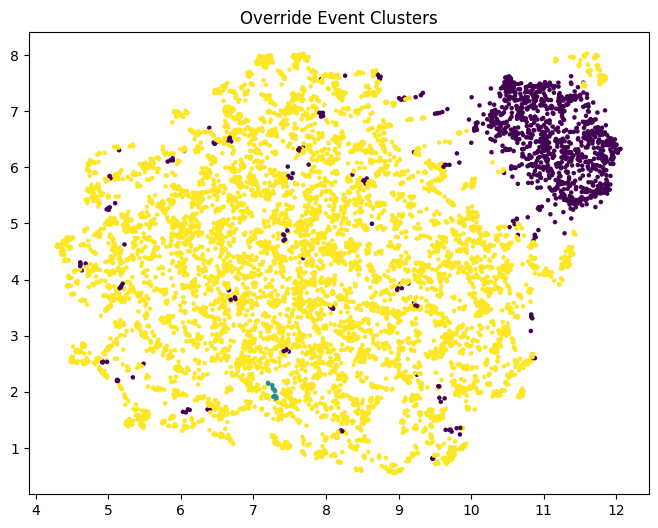

In [21]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.1
)

embedding_2d = reducer.fit_transform(embeddings)

plt.figure(figsize=(8,6))
plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=labels,
    s=5
)
plt.title("Override Event Clusters")
plt.show()

In [22]:
event_cluster = pd.DataFrame({
    "event_id": event_ids,
    "cluster": labels
})

df = df.merge(event_cluster, on="event_id")

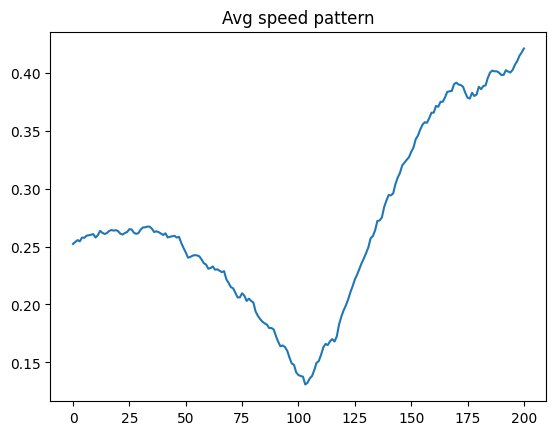

In [26]:
cluster = 0

cluster_events = X_scaled[labels == cluster]

avg_series = cluster_events.mean(axis=0)

plt.plot(avg_series[:, feature_cols.index("CCVS1_Engine.WheelBasedVehicleSpeed")])
plt.title("Avg speed pattern")
plt.show()

## x2vec style

In [10]:
print(X_scaled.shape)

(7938, 201, 22)


In [11]:
import torch

device = torch.device("mps" if torch.mps.is_available() else "cpu")

X_tensor = torch.tensor(X_scaled).float().to(device)

In [12]:
import torch.nn as nn

class TemporalEncoder(nn.Module):

    def __init__(self, input_dim, hidden_dim=128, output_dim=64):
        super().__init__()

        self.network = nn.Sequential(
            nn.Conv1d(input_dim, hidden_dim, 3, padding=1),
            nn.ReLU(),
            nn.Conv1d(hidden_dim, hidden_dim, 3, padding=1),
            nn.ReLU(),
            nn.Conv1d(hidden_dim, hidden_dim, 3, padding=1),
            nn.ReLU()
        )

        self.projection = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):

        # x: [B, T, F]
        x = x.permute(0,2,1)   # [B, F, T]

        h = self.network(x)    # [B, H, T]

        h = h.mean(dim=2)      # global temporal pooling

        z = self.projection(h)

        return z

In [13]:
import torch

def augment(x):

    noise = torch.randn_like(x) * 0.02

    scale = 1 + torch.randn(x.shape[0],1,1,device=x.device)*0.05

    return x * scale + noise

In [14]:
import torch.nn.functional as F

def contrastive_loss(z1, z2, temperature=0.1):

    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    logits = torch.matmul(z1, z2.T) / temperature

    labels = torch.arange(z1.size(0)).to(z1.device)

    loss = F.cross_entropy(logits, labels)

    return loss

In [15]:
input_dim = X_tensor.shape[2]

model = TemporalEncoder(input_dim).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [16]:
from torch.utils.data import DataLoader, TensorDataset

dataset = TensorDataset(X_tensor)

loader = DataLoader(
    dataset,
    batch_size=512,
    shuffle=True
)

epochs = 60

for epoch in range(epochs):

    total_loss = 0

    for (batch,) in loader:

        optimizer.zero_grad()

        x1 = augment(batch)
        x2 = augment(batch)

        z1 = model(x1)
        z2 = model(x2)

        loss = contrastive_loss(z1, z2)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: {total_loss/len(loader):.4f}")

Epoch 1: 2.2276
Epoch 2: 1.0521
Epoch 3: 0.6320
Epoch 4: 0.4327
Epoch 5: 0.3301
Epoch 6: 0.2749
Epoch 7: 0.2324
Epoch 8: 0.2016
Epoch 9: 0.1811
Epoch 10: 0.1729
Epoch 11: 0.1533
Epoch 12: 0.1479
Epoch 13: 0.1436
Epoch 14: 0.1339
Epoch 15: 0.1280
Epoch 16: 0.1248
Epoch 17: 0.1236
Epoch 18: 0.1150
Epoch 19: 0.1142
Epoch 20: 0.1105
Epoch 21: 0.1060
Epoch 22: 0.1036
Epoch 23: 0.1015
Epoch 24: 0.1001
Epoch 25: 0.1005
Epoch 26: 0.0955
Epoch 27: 0.0937
Epoch 28: 0.0935
Epoch 29: 0.0939
Epoch 30: 0.0913
Epoch 31: 0.0893
Epoch 32: 0.0862
Epoch 33: 0.0862
Epoch 34: 0.0869
Epoch 35: 0.0870
Epoch 36: 0.0868
Epoch 37: 0.0820
Epoch 38: 0.0831
Epoch 39: 0.0815
Epoch 40: 0.0807
Epoch 41: 0.0796
Epoch 42: 0.0785
Epoch 43: 0.0765
Epoch 44: 0.0761
Epoch 45: 0.0759
Epoch 46: 0.0761
Epoch 47: 0.0758
Epoch 48: 0.0741
Epoch 49: 0.0758
Epoch 50: 0.0751
Epoch 51: 0.0754
Epoch 52: 0.0728
Epoch 53: 0.0732
Epoch 54: 0.0724
Epoch 55: 0.0726
Epoch 56: 0.0717
Epoch 57: 0.0725
Epoch 58: 0.0714
Epoch 59: 0.0700
Epoch 

In [17]:
model.eval()

embeddings = []

with torch.no_grad():

    for i in range(0, len(X_tensor), 256):

        batch = X_tensor[i:i+256]

        z = model(batch)

        embeddings.append(z.cpu())

embeddings = torch.cat(embeddings).numpy()

print(embeddings.shape)

(7938, 64)


In [18]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=3,
    min_samples=1
)

labels = clusterer.fit_predict(embeddings)

print("Clusters found:", len(set(labels)) - (1 if -1 in labels else 0))

Clusters found: 3


/Users/jonathan/umsi/SI699/Traxen_Driver_Override/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


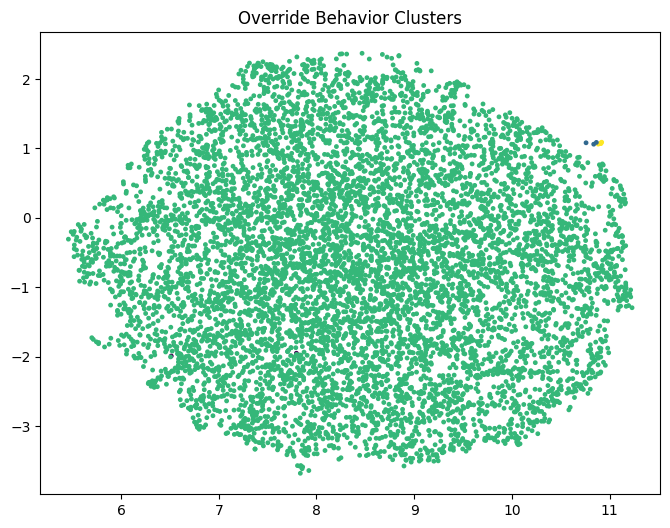

In [19]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1
)

vis = reducer.fit_transform(embeddings)

plt.figure(figsize=(8,6))

plt.scatter(
    vis[:,0],
    vis[:,1],
    c=labels,
    s=6
)

plt.title("Override Behavior Clusters")

plt.show()

In [20]:
cluster_df = pd.DataFrame({
    "event_id": event_ids,
    "cluster": labels
})

df = df.merge(cluster_df, on="event_id")

In [25]:
df.columns

Index(['Timestamp', 'iQC1.iQCMode', 'EH_not_localized.EH_not_localized',
       'VP_RP_80.Latitude', 'VP_RP_80.Longitude', 'EEC2_Engine.AccelPedalPos1',
       'CCVS1_Engine.BrakeSwitch', 'EBC1_Brakes.BrakePedalPos',
       'CCVS1_Engine.WheelBasedVehicleSpeed',
       'ACC1_Radar.DistanceToForwardVehicle',
       'ACC1_Radar.SpeedOfForwardVehicle', 'ACC1_Radar.TargetDetected',
       'ARI_RP.YawRateExRange', 'IQVS1.iQRoadGrade', 'VDS_RP_80.Altitude',
       'ACC1.RoadCurvature', 'CCVS1_Engine.CruiseCtrlSetSpeed',
       'IQPC1.iQReferenceSpeed', 'IQPC1.iQMaximumSpeed',
       'IQPC1.iQMinimumSpeed', 'IQVLPE1.iQGrossVehicleWeightEst',
       'EEC1_Engine.EngSpeed', 'EEC1_Engine.ActualEngPercentTorque',
       'EEC1_Engine.DriversDemandEngPercentTorque',
       'ERC1_Retarder.ActualRetarderPercentTorque', 'truck_id', 'event_id',
       'override_type', 'override_ts', 'is_override_point',
       'PCC1.RoadwayNextGradeDis', 'PCC1.RoadwayNextGrade',
       'IQCU_IMU_Status_4.PathCurvature'

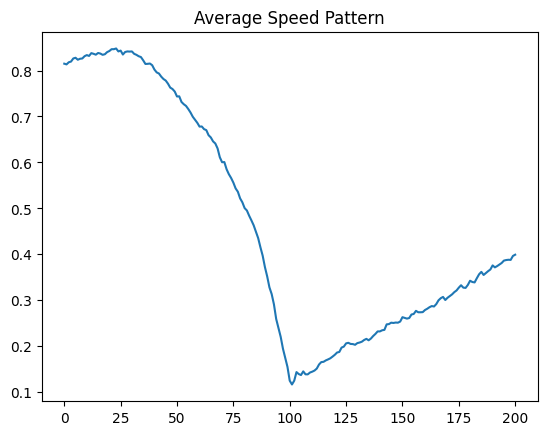

In [24]:
cluster = 2

cluster_events = X_scaled[labels == cluster]

avg_pattern = cluster_events.mean(axis=0)

plt.plot(avg_pattern[:, feature_cols.index("CCVS1_Engine.WheelBasedVehicleSpeed")])
plt.title("Average Speed Pattern")
plt.show()

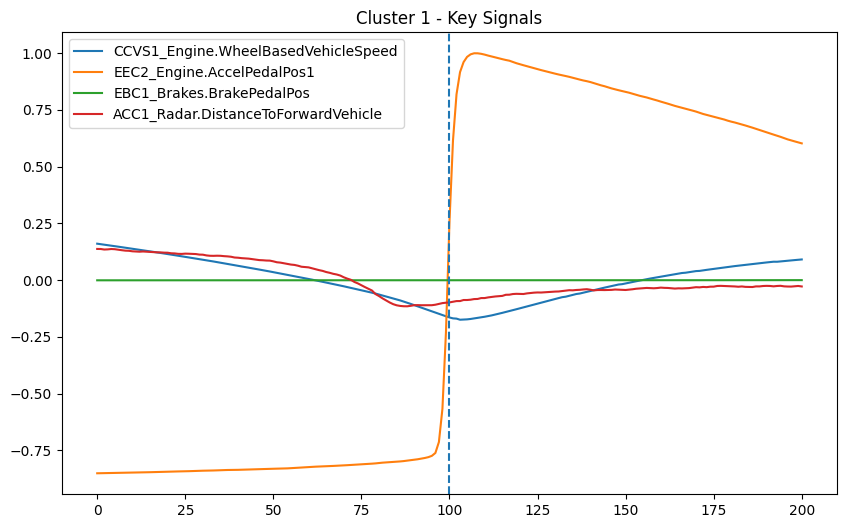

In [28]:
cluster = 1

cluster_events = X_scaled[labels == cluster]

avg_pattern = cluster_events.mean(axis=0)

signals = [
    "CCVS1_Engine.WheelBasedVehicleSpeed",
    "EEC2_Engine.AccelPedalPos1",
    "EBC1_Brakes.BrakePedalPos",
    "ACC1_Radar.DistanceToForwardVehicle"
]

plt.figure(figsize=(10,6))

for s in signals:
    idx = feature_cols.index(s)
    plt.plot(avg_pattern[:, idx], label=s)

plt.axvline(100, linestyle="--")  # override point
plt.legend()
plt.title(f"Cluster {cluster} - Key Signals")
plt.show()

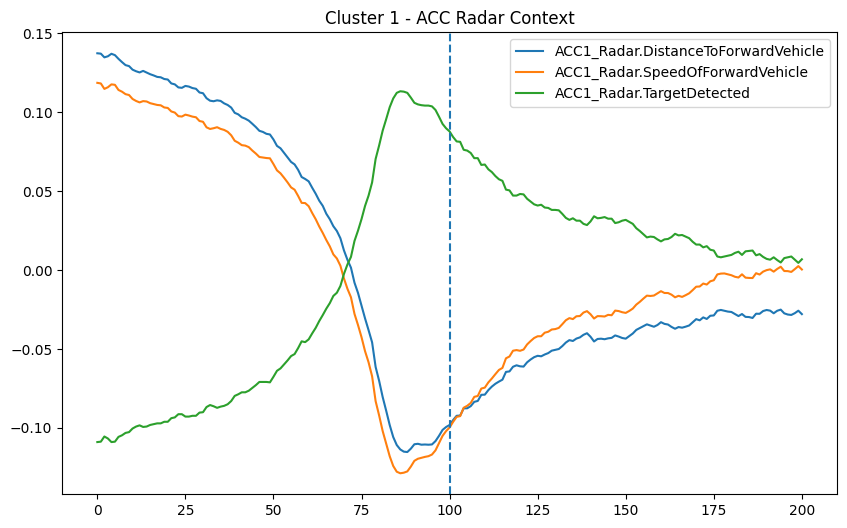

In [29]:
signals = [
    "ACC1_Radar.DistanceToForwardVehicle",
    "ACC1_Radar.SpeedOfForwardVehicle",
    "ACC1_Radar.TargetDetected"
]

plt.figure(figsize=(10,6))

for s in signals:
    idx = feature_cols.index(s)
    plt.plot(avg_pattern[:, idx], label=s)

plt.axvline(100, linestyle="--")
plt.legend()
plt.title(f"Cluster {cluster} - ACC Radar Context")
plt.show()

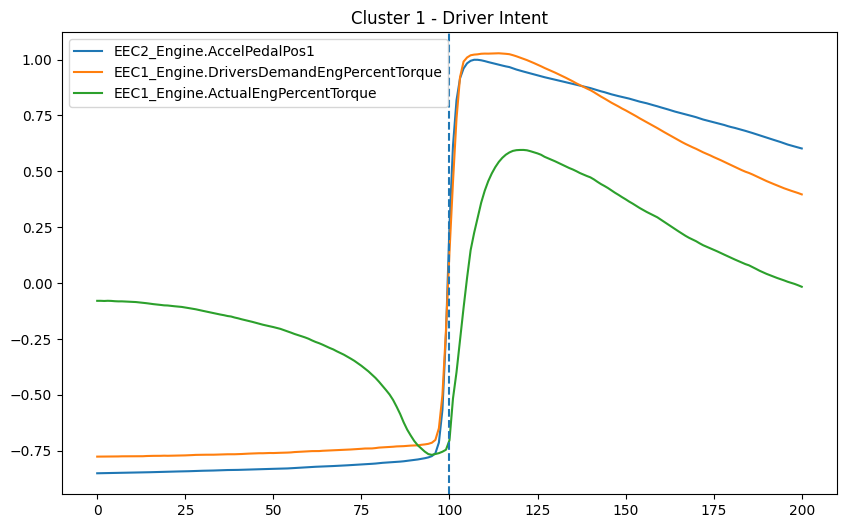

In [30]:
signals = [
    "EEC2_Engine.AccelPedalPos1",
    "EEC1_Engine.DriversDemandEngPercentTorque",
    "EEC1_Engine.ActualEngPercentTorque"
]

plt.figure(figsize=(10,6))

for s in signals:
    idx = feature_cols.index(s)
    plt.plot(avg_pattern[:, idx], label=s)

plt.axvline(100, linestyle="--")
plt.legend()
plt.title(f"Cluster {cluster} - Driver Intent")
plt.show()

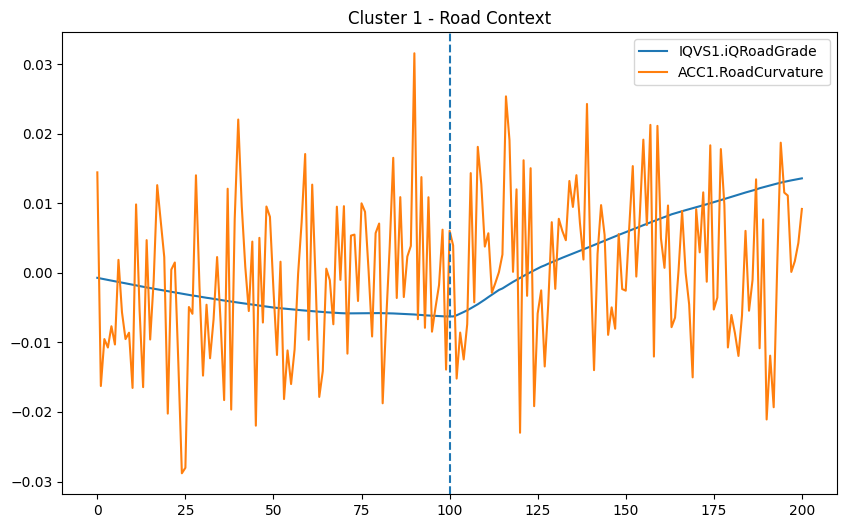

In [33]:
signals = [
    "IQVS1.iQRoadGrade",
    # "PCC1.RoadwayNextGrade",
    "ACC1.RoadCurvature",
    # "IQCU_IMU_Status_4.PathCurvature"
]

plt.figure(figsize=(10,6))

for s in signals:
    idx = feature_cols.index(s)
    plt.plot(avg_pattern[:, idx], label=s)

plt.axvline(100, linestyle="--")
plt.legend()
plt.title(f"Cluster {cluster} - Road Context")
plt.show()

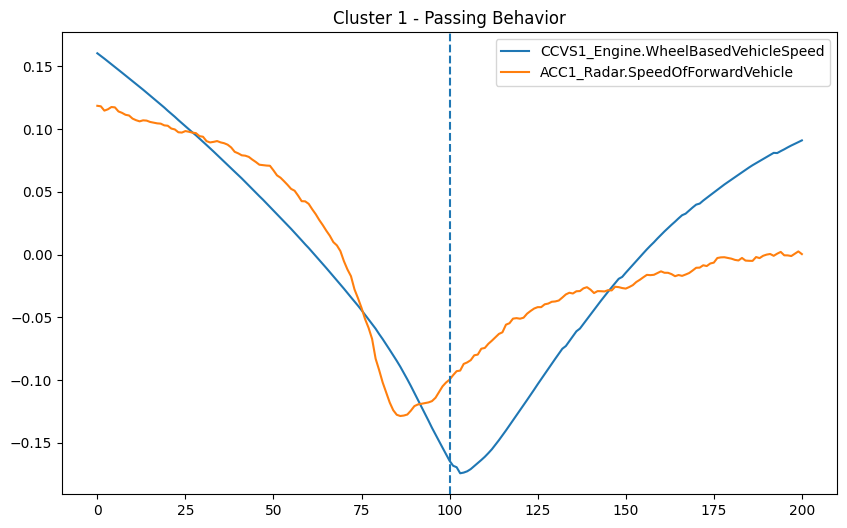

In [34]:
signals = [
    "CCVS1_Engine.WheelBasedVehicleSpeed",
    "ACC1_Radar.SpeedOfForwardVehicle"
]

plt.figure(figsize=(10,6))

for s in signals:
    idx = feature_cols.index(s)
    plt.plot(avg_pattern[:, idx], label=s)

plt.axvline(100, linestyle="--")
plt.legend()
plt.title(f"Cluster {cluster} - Passing Behavior")
plt.show()

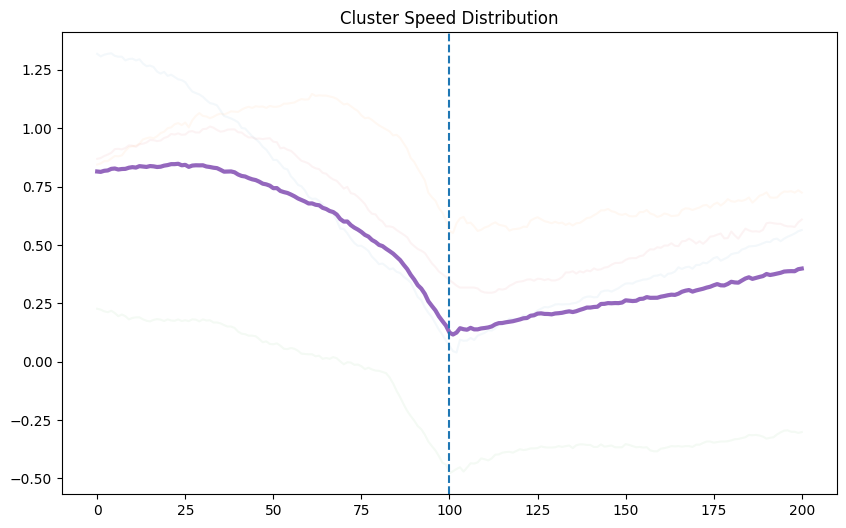

In [35]:
cluster = 2
cluster_events = X_scaled[labels == cluster]

idx = feature_cols.index("CCVS1_Engine.WheelBasedVehicleSpeed")

plt.figure(figsize=(10,6))

for e in cluster_events[:100]:
    plt.plot(e[:, idx], alpha=0.05)

plt.plot(cluster_events.mean(axis=0)[:, idx], linewidth=3)

plt.axvline(100, linestyle="--")
plt.title("Cluster Speed Distribution")
plt.show()

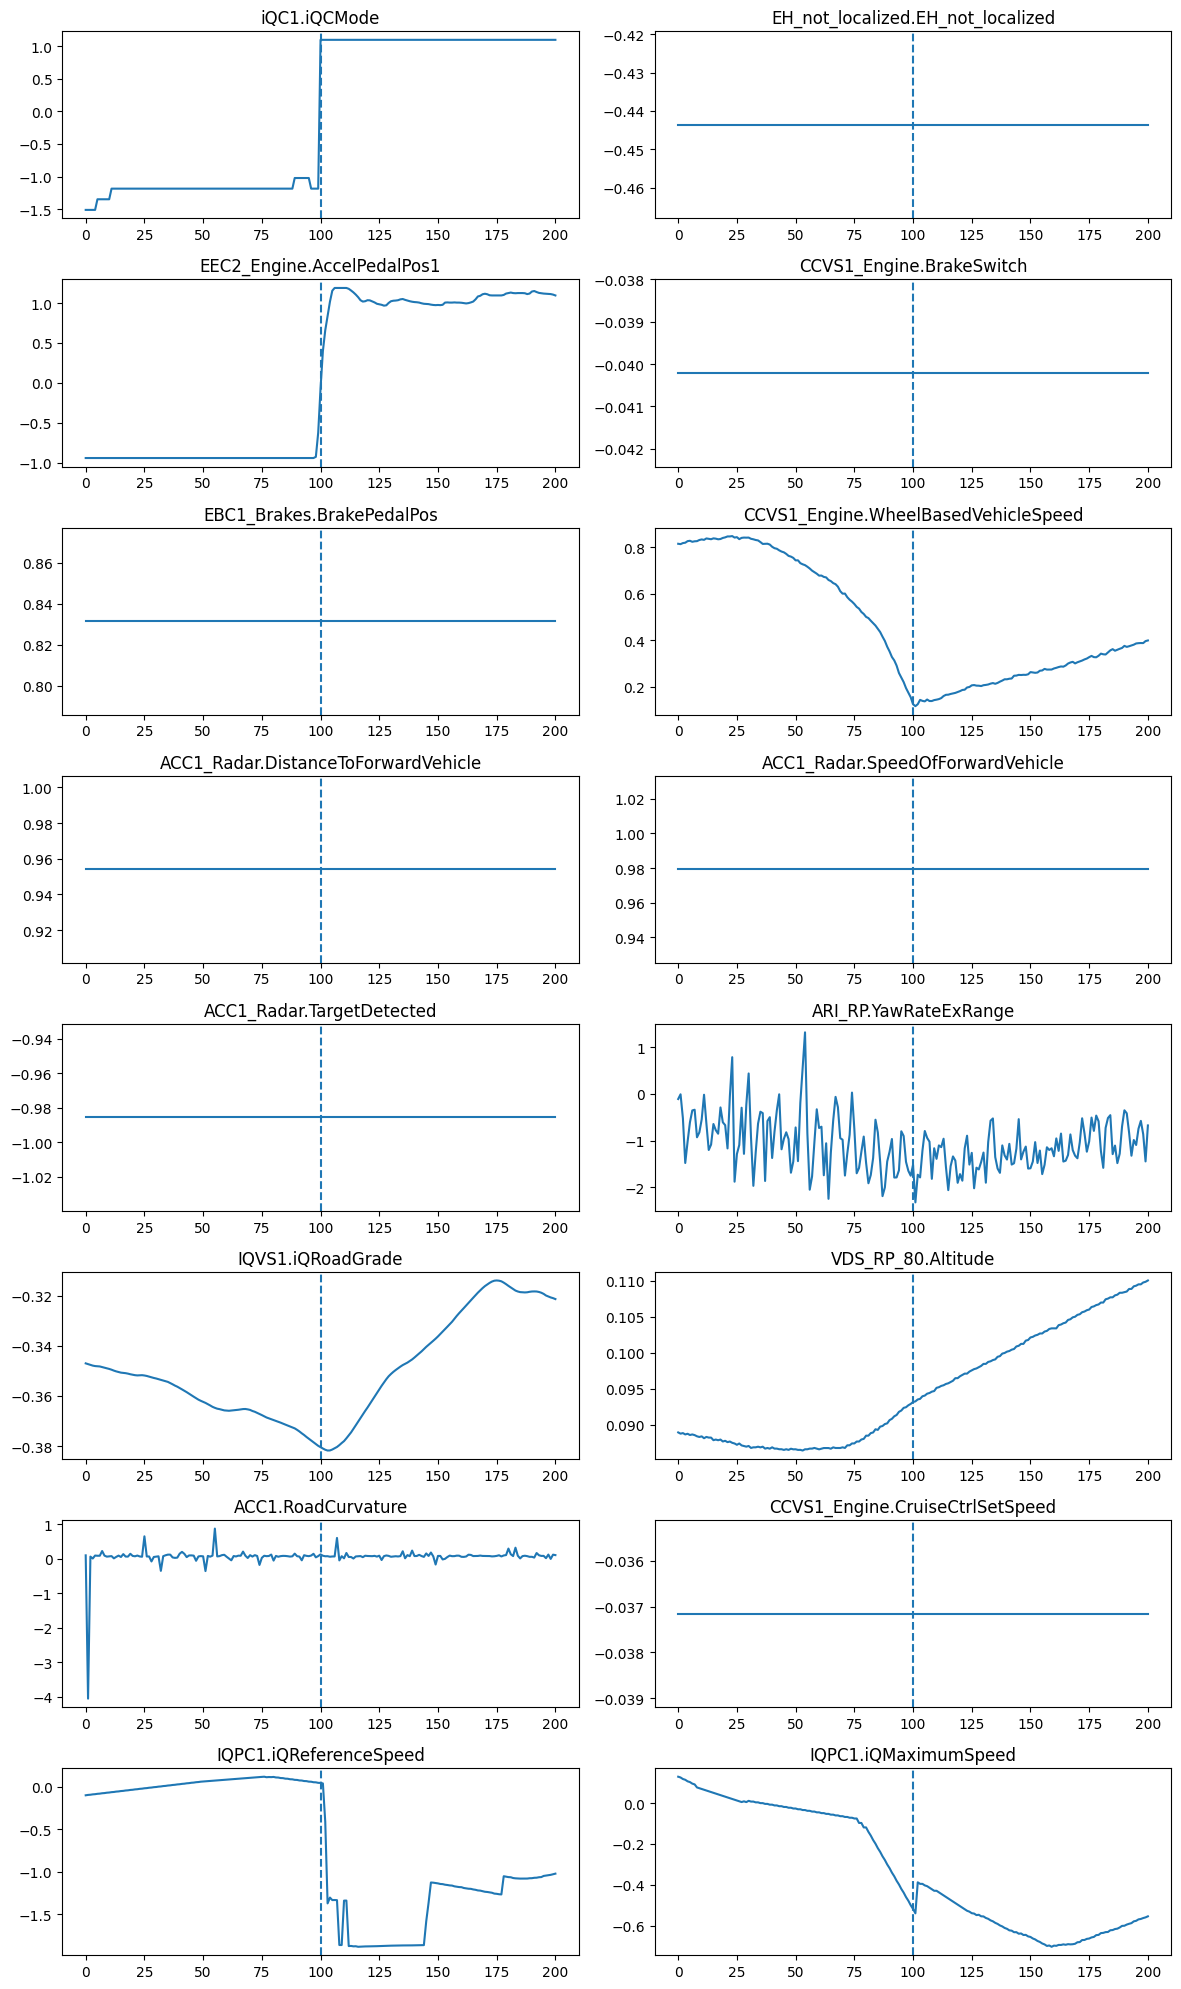

In [39]:
cluster = 2

cluster_events = X_scaled[labels == cluster]
avg_pattern = cluster_events.mean(axis=0)

plt.figure(figsize=(12,20))

for i, f in enumerate(feature_cols[:16]):

    plt.subplot(8,2,i+1)

    plt.plot(avg_pattern[:, i])
    plt.axvline(100, linestyle="--")
    plt.title(f)

plt.tight_layout()
plt.show()

## OLD CODE

## summary clustering

In [1]:
from pathlib import Path
import pandas as pd
from tqdm import tqdm


base = Path("../temp/event_windows")

files = list(base.glob("*/*.csv"))

dfs = []

for f in tqdm(files, desc="reading files"):
    df = pd.read_csv(f)
    df["source_file"] = f.name
    dfs.append(df)

reading files: 100%|██████████| 10192/10192 [00:24<00:00, 422.16it/s]


In [6]:
import numpy as np


def extract_features(df):

    df = df.drop(columns=[
        "Timestamp",
        "is_override_point",
        "VP_RP_80.Latitude",
        "VP_RP_80.Longitude",
        "VDS_FC.Altitude"
    ], errors="ignore")

    features = {}

    for col in df.columns:

        x = df[col].values

        features[f"{col}_mean"] = np.nanmean(x)
        features[f"{col}_std"] = np.nanstd(x)
        features[f"{col}_min"] = np.nanmin(x)
        features[f"{col}_max"] = np.nanmax(x)
        features[f"{col}_delta"] = np.nan_to_num(x[-1]) - np.nan_to_num(x[0])

        mask = ~np.isnan(x)

        if mask.sum() > 2:
            slope = np.polyfit(np.arange(len(x))[mask], x[mask], 1)[0]
        else:
            slope = 0

        features[f"{col}_slope"] = slope

    return features

rows = #files

columns ≈ (#signals × 6 features)

In [7]:
rows = []
names = []

for f in tqdm(files, desc="creating data"):
    df = pd.read_csv(f)
    rows.append(extract_features(df))
    names.append(f.name)

X = pd.DataFrame(rows)
X.index = names

creating data: 100%|██████████| 10192/10192 [01:40<00:00, 101.24it/s]


In [8]:
X.isna().sum().sort_values(ascending=False).head()

iQC1.iQCMode_mean     0
iQC1.iQCMode_std      0
iQC1.iQCMode_min      0
iQC1.iQCMode_max      0
iQC1.iQCMode_delta    0
dtype: int64

In [9]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
from sklearn.decomposition import PCA


pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

In [12]:
import hdbscan


clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,
    min_samples=3
)

labels = clusterer.fit_predict(X_pca)

/home/jrmcmill/Traxen_Driver_Override/.venv/lib/python3.13/site-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [13]:
results = pd.DataFrame({
    "file": names,
    "cluster": labels
})

results.sort_values("cluster")

,file,cluster
40,event_179_THROTTLE_OVERRIDE_2025-11-02_04-11-2...,-1
9798,event_800_UNKNOWN_2025-11-25_00-46-09.017000.csv,-1
9751,event_1035_UNKNOWN_2025-11-26_06-26-46.156000.csv,-1
9713,event_651_UNKNOWN_2025-11-22_01-33-35.289000.csv,-1
9570,event_003_UNKNOWN_2025-11-17_00-20-17.516000.csv,-1
...,...,...
10188,event_547_THROTTLE_OVERRIDE_2025-11-22_00-06-4...,2
10189,event_252_THROTTLE_OVERRIDE_2025-11-20_02-31-0...,2
10190,event_144_THROTTLE_OVERRIDE_2025-11-19_01-49-2...,2
10191,event_877_UNKNOWN_2025-11-25_01-58-30.420000.csv,2


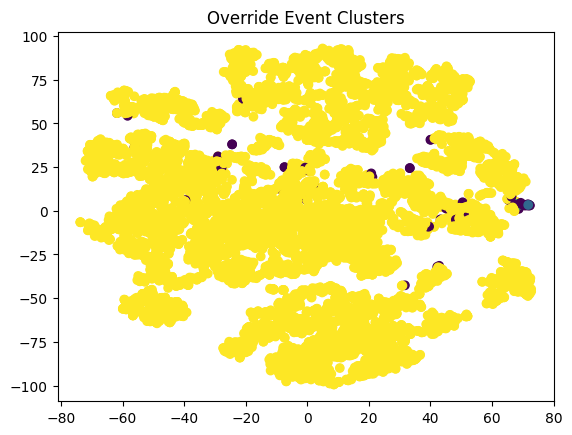

In [14]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


emb = TSNE(n_components=2).fit_transform(X_pca)

plt.scatter(emb[:,0], emb[:,1], c=labels)
plt.title("Override Event Clusters")
plt.show()

## embedding clustering

In [16]:
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler

import umap
import hdbscan

import matplotlib.pyplot as plt

/home/jrmcmill/Traxen_Driver_Override/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
base = Path("../temp/event_windows")

files = list(base.glob("*/*.csv"))

print("Total event files:", len(files))

Total event files: 10192


In [18]:
DROP_COLS = [
    "Timestamp",
    "is_override_point",
    "VP_RP_80.Latitude",
    "VP_RP_80.Longitude",
    "VDS_FC.Altitude",
    "EH_not_localized.EH_not_localized"
]

200 rows × signals → flattened vector

In [20]:
vectors = []
file_names = []

for f in tqdm(files, desc="Processing events"):

    df = pd.read_csv(f)

    # drop unwanted columns
    df = df.drop(columns=DROP_COLS, errors="ignore")

    # convert obvious invalid sensor values
    df.replace([255, 65535], np.nan, inplace=True)

    # forward/backward fill (pandas >=2.1 compatible)
    df = df.ffill().bfill().fillna(0)

    # ensure consistent column ordering
    df = df.sort_index(axis=1)

    # flatten time-series window → vector
    vec = df.to_numpy().flatten()

    vectors.append(vec)
    file_names.append(f.name)

# convert to matrix
X = np.vstack(vectors)

print("Feature matrix shape:", X.shape)

Processing events: 100%|██████████| 10192/10192 [00:41<00:00, 242.74it/s]


Feature matrix shape: (10192, 4200)


In [21]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [22]:
umap_model = umap.UMAP(
    n_neighbors=20,
    n_components=15,
    min_dist=0.0,
    metric="euclidean",
    random_state=42
)

X_embedding = umap_model.fit_transform(X_scaled)

print(X_embedding.shape)

/home/jrmcmill/Traxen_Driver_Override/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(10192, 15)


In [23]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom"
)

labels = clusterer.fit_predict(X_embedding)

print("Clusters found:", len(set(labels)) - (1 if -1 in labels else 0))

Clusters found: 42


-1 = noise / outliers

0..N = clusters

In [24]:
results = pd.DataFrame({
    "file": file_names,
    "cluster": labels
})

results.sort_values("cluster").head(20)

,file,cluster
901,event_601_THROTTLE_OVERRIDE_2025-11-06_01-00-3...,-1
910,event_1759_THROTTLE_OVERRIDE_2025-11-16_02-24-...,-1
912,event_955_UNKNOWN_2025-11-09_01-03-02.689000.csv,-1
9960,event_811_THROTTLE_OVERRIDE_2025-11-25_00-55-2...,-1
8544,event_448_THROTTLE_OVERRIDE_2025-11-09_12-47-5...,-1
8547,event_728_THROTTLE_OVERRIDE_2025-11-14_04-39-1...,-1
8555,event_148_THROTTLE_OVERRIDE_2025-11-04_03-11-1...,-1
8556,event_108_THROTTLE_OVERRIDE_2025-11-04_00-58-3...,-1
918,event_2417_THROTTLE_OVERRIDE_2025-11-23_03-19-...,-1
924,event_170_THROTTLE_OVERRIDE_2025-11-02_03-42-2...,-1


In [25]:
results["cluster"].value_counts().sort_index()

cluster
-1      725
 0     4255
 1      482
 2      164
 3       74
 4      118
 5     1952
 6       97
 7       11
 8       54
 9       25
 10      65
 11      37
 12      21
 13     211
 14     131
 15      69
 16      17
 17      13
 18      40
 19      20
 20     188
 21      60
 22      23
 23      29
 24      12
 25      39
 26      29
 27      58
 28      23
 29      12
 30     277
 31      22
 32      26
 33      21
 34      10
 35      45
 36      12
 37      43
 38      90
 39      31
 40     435
 41     126
Name: count, dtype: int64

In [26]:
umap_2d = umap.UMAP(
    n_neighbors=20,
    n_components=2,
    min_dist=0.0,
    metric="euclidean",
    random_state=42
)

X_2d = umap_2d.fit_transform(X_scaled)

/home/jrmcmill/Traxen_Driver_Override/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


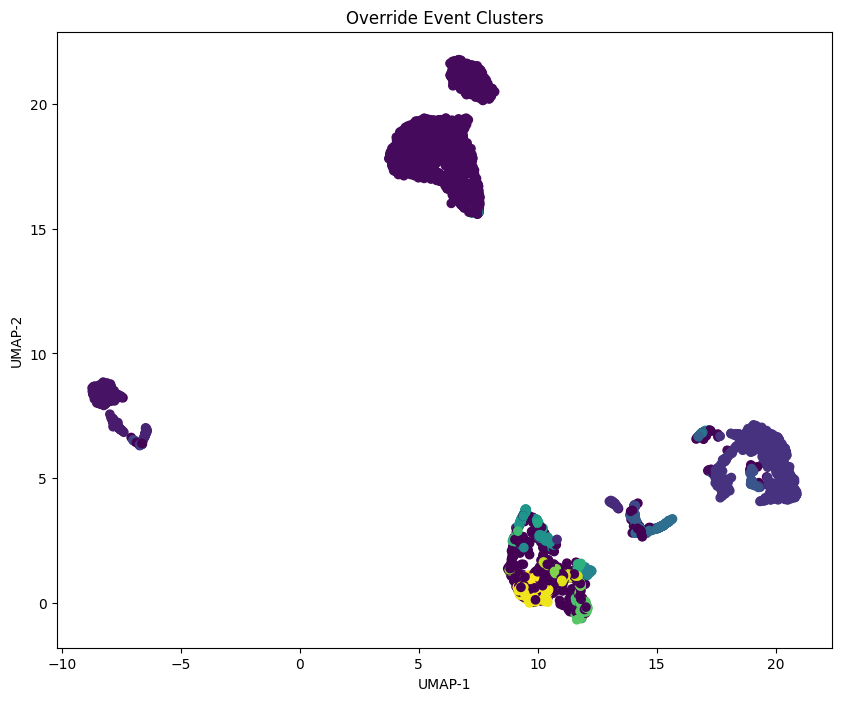

In [27]:
plt.figure(figsize=(10,8))

scatter = plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=labels,
)

plt.title("Override Event Clusters")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.show()

In [28]:
cluster_id = 0

cluster_files = results[results.cluster == cluster_id]["file"]

cluster_files.head()

0    event_1122_UNKNOWN_2025-11-10_02-00-02.360000.csv
1    event_2190_BRAKE_PEDAL_2025-11-21_02-30-38.267...
2    event_1312_THROTTLE_OVERRIDE_2025-11-11_02-17-...
3    event_2163_THROTTLE_OVERRIDE_2025-11-21_01-16-...
4    event_1316_THROTTLE_OVERRIDE_2025-11-11_02-20-...
Name: file, dtype: str

In [29]:
results.to_csv("override_event_clusters.csv", index=False)